# TASK 1A

In [107]:
!pip install seaborn
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [109]:
df = pd.read_csv('ODI-2026.csv', sep=';', encoding='utf-8-sig')

In [110]:
#Show the number of rows and columns
print("Shape: ", df.shape)

Shape:  (156, 16)


In [111]:
#Show the column names and the data type of each column
print("\nColumn names:\n", df.columns.tolist())
print("\nData types: \n",df.dtypes)


Column names:
 ['Tijdstempel', 'What programme are you in?', 'Have you taken a course on machine learning?', 'Have you taken a course on information retrieval?', 'Have you taken a course on statistics?', 'Have you taken a course on databases?', 'What is your gender?', 'I have used LLMs to help me with some of my study assignments ', 'When is your birthday (date)?', 'How many students do you estimate there are in the room?', 'What is your stress level (0-100)?', 'How many hours per week do you do sports (in whole hours)? ', 'Give a random number', 'Time you went to bed Yesterday', 'What makes a good day for you (1)?', 'What makes a good day for you (2)?']

Data types: 
 Tijdstempel                                                       object
What programme are you in?                                        object
Have you taken a course on machine learning?                      object
Have you taken a course on information retrieval?                 object
Have you taken a course on st

##### The columns: Tijdstempel, Birthday date, Number of students, Stresslevel, Hours per week sports, Random number and Time went to bed are actually numbers and supposed to be integer, floats or datetime, but are actually objects (text) in the file. 

In [112]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Tijdstempel,What programme are you in?,Have you taken a course on machine learning?,Have you taken a course on information retrieval?,Have you taken a course on statistics?,Have you taken a course on databases?,What is your gender?,I have used LLMs to help me with some of my study assignments,When is your birthday (date)?,How many students do you estimate there are in the room?,What is your stress level (0-100)?,How many hours per week do you do sports (in whole hours)?,Give a random number,Time you went to bed Yesterday,What makes a good day for you (1)?,What makes a good day for you (2)?
0,3-31-2026 12:20:14,AI,yes,0,mu,nee,non-binary,yes,27/6/2001,200,0,10,67,3:30,Pagga,Pagga
1,3-31-2026 12:20:19,AI,yes,1,mu,ja,male,no,31.01.97,500,20,0,42,24:00,Sun,No rain
2,3-31-2026 12:20:20,"Masters in Science, Artificial Intelligence",yes,0,mu,ja,male,yes,15-03-2001,120,70,2,42,4,Productive Day,Indulging in Hobbies
3,3-31-2026 12:20:34,Systems biology & bioinformatics,yes,0,mu,ja,female,yes,5 November,310,0,8,67,22:00,Social interactions,Good weather
4,3-31-2026 12:20:39,AI,yes,1,mu,ja,female,yes,14-01-2002,250,30,7,55,22.15,Sun,Sports


We see that the values in the columns are not consistent; numbers, names, time, age. Almost every columns consists of data of different format. This might be the reason why the formats are all objects: since the columns consist variables of different formats, Pandas is forced to treat the variables in every column as text. 

In [113]:
#Check for missing values in the entire dataset; we know from above: Rows=156 and Columns=16
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 16 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   Tijdstempel                                                     156 non-null    object
 1   What programme are you in?                                      156 non-null    object
 2   Have you taken a course on machine learning?                    156 non-null    object
 3   Have you taken a course on information retrieval?               156 non-null    object
 4   Have you taken a course on statistics?                          156 non-null    object
 5   Have you taken a course on databases?                           156 non-null    object
 6   What is your gender?                                            156 non-null    object
 7   I have used LLMs to help me with some of my study assignments 

This seems correct. I also checked the excel file. There are no Null-values. There are "Unknown"-values in certain rows, so data is missing, but no empty cells.

In [114]:
#Analyse the data for empty strings
print("Empty strings per column:")
print((df == '').sum())

Empty strings per column:
Tijdstempel                                                       0
What programme are you in?                                        0
Have you taken a course on machine learning?                      0
Have you taken a course on information retrieval?                 0
Have you taken a course on statistics?                            0
Have you taken a course on databases?                             0
What is your gender?                                              0
I have used LLMs to help me with some of my study assignments     0
When is your birthday (date)?                                     0
How many students do you estimate there are in the room?          0
What is your stress level (0-100)?                                0
How many hours per week do you do sports (in whole hours)?        0
Give a random number                                              0
Time you went to bed Yesterday                                    0
What makes a good day 

In [115]:
#Check for placeholder-values in the rows instead of leaving fields blank
print("\n'Unknown' values per column:")
print((df == 'unknown').sum())


'Unknown' values per column:
Tijdstempel                                                        0
What programme are you in?                                         0
Have you taken a course on machine learning?                       1
Have you taken a course on information retrieval?                 15
Have you taken a course on statistics?                            10
Have you taken a course on databases?                              3
What is your gender?                                               0
I have used LLMs to help me with some of my study assignments      0
When is your birthday (date)?                                      0
How many students do you estimate there are in the room?           0
What is your stress level (0-100)?                                 0
How many hours per week do you do sports (in whole hours)?         0
Give a random number                                               0
Time you went to bed Yesterday                                     0
What

Findings: there are 29 cell-values in total across the dataset where these no-data cells are marked as "unknown". 

In [116]:
#statistical summary of the columns
df.describe(include='all')

,Tijdstempel,What programme are you in?,Have you taken a course on machine learning?,Have you taken a course on information retrieval?,Have you taken a course on statistics?,Have you taken a course on databases?,What is your gender?,I have used LLMs to help me with some of my study assignments,When is your birthday (date)?,How many students do you estimate there are in the room?,What is your stress level (0-100)?,How many hours per week do you do sports (in whole hours)?,Give a random number,Time you went to bed Yesterday,What makes a good day for you (1)?,What makes a good day for you (2)?
count,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156
unique,96,75,3,3,3,3,5,3,153,55,44,22,95,94,119,136
top,3-31-2026 12:21:52,AI,yes,0,mu,ja,male,yes,2002,200,30,2,67,00:30,Sun,Good food
freq,5,25,134,83,122,107,79,115,2,17,17,21,16,10,12,5


###### count = number of rows, unique = number of different values, top = the most frequent occuring value, freq = number of times that the top value occurs.

You can see in the output the following:
1. different languages; this needs to be standardized
2. birthday has 156 rows and 153 unique variables
3. supprisingly are the randomn numbers not so randomn, with 67 occuring 16 times.
4. There are 75 unique programmes, thats a bit much, probably because of names like AI, A.I., Ai, Artificial Inteligence, BA, Business Analytics etc

# Plots

Before being able to make some plots, we need to convert the columns type of certain columns.

In [117]:
# Convert values in the column Stress Level tot numbers, if an error occurs, set the value to NaN
stress = pd.to_numeric(df['What is your stress level (0-100)?'], errors='coerce')


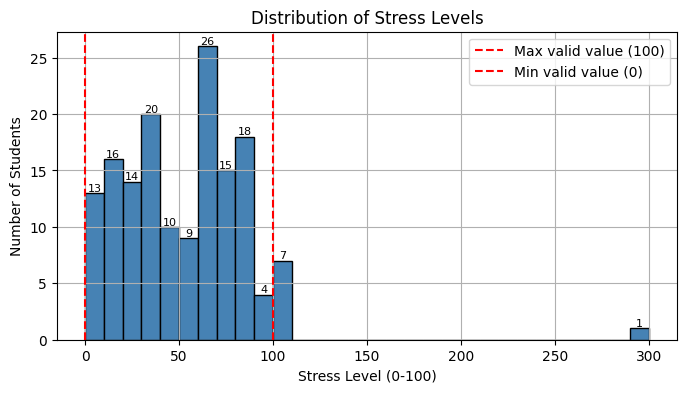

In [118]:
# Plot distribution
plt.figure(figsize=(8, 4))
ax = plt.gca()
bb = range(0, 301, 10)  # bins of width 5
stress.hist(bins=bb, color='steelblue', edgecolor='black', ax=ax)

plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level (0-100)')
plt.ylabel('Number of Students')

plt.axvline(x=100, color='red', linestyle='--', label='Max valid value (100)')
plt.axvline(x=0, color='red', linestyle='--', label='Min valid value (0)')

# Add number on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.legend()
plt.show()


The stresslevel was required to be between 0 up to 100, but there are also values beyond 100. Especially the 300 is an outliers.

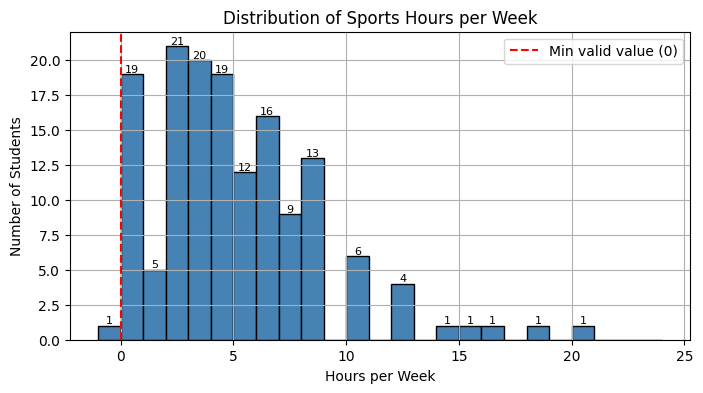

In [119]:
# Convert sportshours to number, force errors to NaN
sports = pd.to_numeric(df['How many hours per week do you do sports (in whole hours)? '], errors='coerce')

# Plot the distribution
plt.figure(figsize=(8, 4))
ax = plt.gca()
bb = range(-1, 25, 1)  # bins of width 1
sports.hist(bins=bb, color='steelblue', edgecolor='black', ax=ax)

#plt.axvline(x=168, color='red', linestyle='--', label='Max valid value (168hrs = 1 week)')
plt.axvline(x=0, color='red', linestyle='--', label='Min valid value (0)')

# Add number on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.legend()
plt.title('Distribution of Sports Hours per Week')
plt.xlabel('Hours per Week')
plt.ylabel('Number of Students')
plt.show()


There are students who sport negative hours in a week

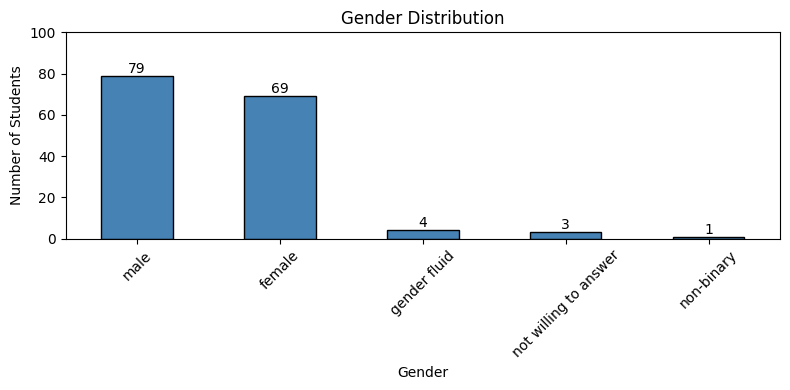

In [120]:
# Count occurrences of each gender value
gender_counts = df['What is your gender?'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 4))
ax = gender_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.ylim(0, 100)
plt.xticks(rotation=45)

# Add number on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


The dataset contains 5 gender categories: male, female, gender fluid, not willing to answer, and non-binary
The majority identifies as male (79) or female (69).
The values are consistent, in contrary to the other columns.

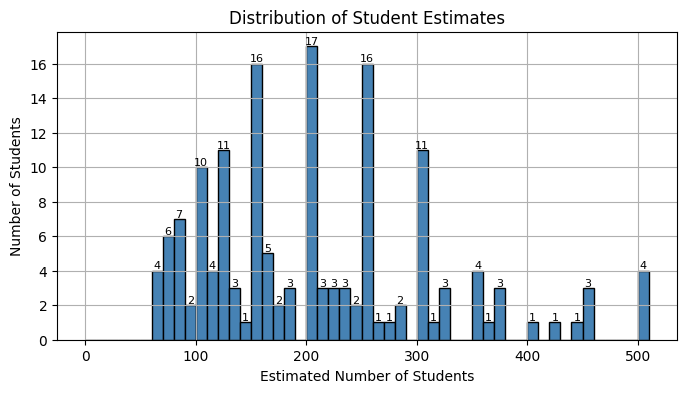

In [121]:
# Convert student estimates to numeric
students = pd.to_numeric(df['How many students do you estimate there are in the room?'], errors='coerce')

# Plot distribution
plt.figure(figsize=(8, 4))
ax = plt.gca()
bb = range(0, 520, 10)  # bins of width 10
students.hist(bins=bb, color='steelblue', edgecolor='black', ax=ax)

# Add number on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.title('Distribution of Student Estimates')
plt.xlabel('Estimated Number of Students')
plt.ylabel('Number of Students')
plt.show()


Estimates range from 65 to 500 students.
The numbers 200 and 250 are the most common answers (17 and 16 students respectively), suggesting people rounded to nice numbers rather than giving precise estimates.
The number 500 appears 4 times, an very high number for a single lecture room.
The wide spread (65–500) shows high uncertainty in crowd estimation.

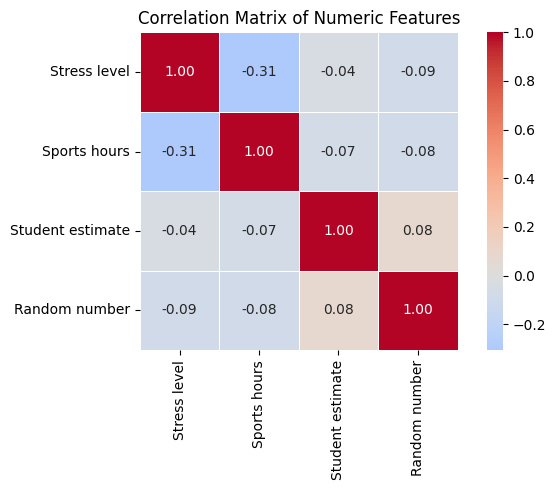

In [122]:
# Correlation analysis between numeric attributes
#
# To study relationships between attributes, we compute a correlation matrix.
# Correlation ranges from -1 (perfect negative) to +1 (perfect positive).
# Values close to 0 mean little to no linear relationship.
#
# We can only correlate numeric columns — so we convert them first.

numeric_cols = {
    'Stress level': pd.to_numeric(df['What is your stress level (0-100)?'], errors='coerce'),
    'Sports hours': pd.to_numeric(df['How many hours per week do you do sports (in whole hours)? '], errors='coerce'),
    'Student estimate': pd.to_numeric(df['How many students do you estimate there are in the room?'], errors='coerce'),
    'Random number': pd.to_numeric(df['Give a random number'], errors='coerce')
}

df_numeric = pd.DataFrame(numeric_cols)

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Plot as heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


The correlation matrix shows the linear relationships between the four numeric attributes.

Most correlations are close to 0, meaning those attributes carry largely independent information — a good sign for machine learning, as it reduces redundancy.

The most notable relationship is between stress level and sports hours: **-0.31**. This moderate negative correlation suggests that students who do more sport tend to report lower stress levels. While correlation does not imply causation, this is an interesting pattern worth exploring further.

All other correlations (student estimates, random number) are near zero, as expected — student estimates vary widely and the random number was randomly generated.

# TASK 1B

For task 1B we'll make a copy of the file so the original stays untouched.

In [123]:
# Work on a copy so the original data is preserved
df_clean = df.copy()

# Convert to numeric to detect outliers
df_clean['stress'] = pd.to_numeric(df_clean['What is your stress level (0-100)?'], errors='coerce')
df_clean['sports'] = pd.to_numeric(df_clean['How many hours per week do you do sports (in whole hours)? '], errors='coerce')

# Print outliers
print("Stress outliers (outside 0-100):")
print(df_clean[df_clean['stress'] > 100]['stress'])

print("\nSports outliers (negative values):")
print(df_clean[df_clean['sports'] < 0]['sports'])

Stress outliers (outside 0-100):
12    101.0
14    101.0
39    300.0
Name: stress, dtype: float64

Sports outliers (negative values):
12   -1.0
Name: sports, dtype: float64


In [124]:
# Set invalid stress values to NaN
df_clean.loc[df_clean['stress'] > 100, 'stress'] = None

# Set invalid sports values to NaN
df_clean.loc[df_clean['sports'] < 0, 'sports'] = None

print("Stress NaN count after cleaning:", df_clean['stress'].isna().sum())
print("Sports NaN count after cleaning:", df_clean['sports'].isna().sum())

Stress NaN count after cleaning: 6
Sports NaN count after cleaning: 7


Stress: 6 NaN total after cleaning.
- 3 outliers removed (101, 101, 300) — outside valid range 0-100
- 3 non-numeric entries (e.g. "Yes", "9.999.999", "100 😳") converted to NaN

Sports: 7 NaN total after cleaning.
- 1 outlier removed (-1) — negative hours are physically impossible
- 6 non-numeric entries (e.g. "5-6 hours", "1hr") converted to NaN

In [125]:
# Check what the original non-numeric stress values were
mask = pd.to_numeric(df['What is your stress level (0-100)?'], errors='coerce').isna()
print(df[mask]['What is your stress level (0-100)?'])


55           Yes
79     9.999.999
148        100 😳
Name: What is your stress level (0-100)?, dtype: object


In [126]:
#handle first the numerical imputation, afterwards the categorical.

# Store original NaN positions for comparison
stress_nan_idx = df_clean[df_clean['stress'].isna()].index
sports_nan_idx = df_clean[df_clean['sports'].isna()].index

# --- Approach 1: Mean imputation ---
df_mean = df_clean.copy()
df_mean['stress'] = df_mean['stress'].fillna(df_mean['stress'].mean())
df_mean['sports'] = df_mean['sports'].fillna(df_mean['sports'].mean())

# --- Approach 2: Median imputation ---
df_median = df_clean.copy()
df_median['stress'] = df_median['stress'].fillna(df_median['stress'].median())
df_median['sports'] = df_median['sports'].fillna(df_median['sports'].median())

# Compare the imputed values
print("Stress — Mean imputed values:")
print(df_mean.loc[stress_nan_idx, 'stress'].round(2).values)
print("\nStress — Median imputed values:")
print(df_median.loc[stress_nan_idx, 'stress'].round(2).values)

print("\nSports — Mean imputed values:")
print(df_mean.loc[sports_nan_idx, 'sports'].round(2).values)
print("\nSports — Median imputed values:")
print(df_median.loc[sports_nan_idx, 'sports'].round(2).values)

# print the average values for stress and sports before and after imputation
print("\nAverage stress before imputation:", df_clean['stress'].mean())
print("Average stress after mean imputation:", df_mean['stress'].mean())
print("Average stress after median imputation:", df_median['stress'].mean())
print("\nAverage sports hours before imputation:", df_clean['sports'].mean())
print("Average sports hours after mean imputation:", df_mean['sports'].mean())
print("Average sports hours after median imputation:", df_median['sports'].mean())



Stress — Mean imputed values:
[47.19 47.19 47.19 47.19 47.19 47.19]

Stress — Median imputed values:
[50. 50. 50. 50. 50. 50.]

Sports — Mean imputed values:
[4.68 4.68 4.68 4.68 4.68 4.68 4.68]

Sports — Median imputed values:
[4. 4. 4. 4. 4. 4. 4.]

Average stress before imputation: 47.1866
Average stress after mean imputation: 47.1866
Average stress after median imputation: 47.29480769230769

Average sports hours before imputation: 4.677852348993288
Average sports hours after mean imputation: 4.677852348993288
Average sports hours after median imputation: 4.647435897435898


Numerical imputation comparison:

Stress: mean = 47.19, median = 50.0
Sports: mean = 4.68, median = 4.0

We choose median imputation because the stress distribution is skewed (visible in the histogram) and had outliers (300, 101), which inflate the mean. The median is more robust to outliers. For sports the difference is small, but median is preferred for consistency.


We have 4 columns in our dataset contain 'unknown' values. Pandas doens't threat unknown-values as missing values, but as a valid string value. So we need to convert these values to NaN.

In [127]:
# Define the list of columns that represent yes/no course questions
# These are the only columns that contain 'unknown' as a placeholder for missing data
course_cols = [
    'Have you taken a course on machine learning?',
    'Have you taken a course on information retrieval?',
    'Have you taken a course on statistics?',
    'Have you taken a course on databases?'
]

# Replace the string 'unknown' with pd.NA (pandas missing value)
# We do this because pandas does not treat the text 'unknown' as missing —
# only NaN/pd.NA is recognized as missing, which allows us to impute it later
df_clean[course_cols] = df_clean[course_cols].replace('unknown', pd.NA)

# Verify the replacement worked — should show 1, 15, 10, 3
print("Missing values in course columns after replacement:")
print(df_clean[course_cols].isna().sum())


Missing values in course columns after replacement:
Have you taken a course on machine learning?          1
Have you taken a course on information retrieval?    15
Have you taken a course on statistics?               10
Have you taken a course on databases?                 3
dtype: int64


Looking at the raw data, each course column uses a different format:

Machine learning: yes / no
Information retrieval: 1 / 0
Statistics: mu / sigma (Greek letters — unusual choice)
Databases: ja / nee (Dutch)
As we can see, alot of inconsistency in the data, between the columns and within.
But till this point we only handle the unknown-values.

Now we move to the actual categorical imputation. For these columns the standard approach is mode imputation — replacing missing values with the most frequent value in that column.

Why mode and not mean/median? Because the values are categorical (yes/no), not numbers. You can't calculate a mean of yes/no. The mode — the most common answer — is the logical equivalent for categorical data.

In [128]:
# For categorical columns, we use MODE imputation
# Mode = the most frequently occurring value in a column
# We cannot use mean/median for categorical data (you can't average "yes" and "no")
# The mode is the logical equivalent for categorical columns

for col in course_cols:
    # Calculate the mode of the column (most frequent value)
    # .mode() returns a Series — [0] gets the first (most frequent) value
    mode_value = df_clean[col].mode()[0]
    
    # Fill all NaN values in this column with the mode
    # This replaces the missing values with the most common answer
    df_clean[col] = df_clean[col].fillna(mode_value)
    
    # Print the mode used for each column so we can verify
    print(f"Column: '{col}'")
    print(f"  Mode used for imputation: {mode_value}")
    print(f"  Remaining NaN: {df_clean[col].isna().sum()}\n")


Column: 'Have you taken a course on machine learning?'
  Mode used for imputation: yes
  Remaining NaN: 0

Column: 'Have you taken a course on information retrieval?'
  Mode used for imputation: 0
  Remaining NaN: 0

Column: 'Have you taken a course on statistics?'
  Mode used for imputation: mu
  Remaining NaN: 0

Column: 'Have you taken a course on databases?'
  Mode used for imputation: ja
  Remaining NaN: 0



The modes reflect the majority answer in each column:
- Machine learning: yes (majority said yes)
- Information retrieval: 0 (majority said no)
- Statistics: mu (majority said yes)
- Databases: ja (majority said yes)

Mode imputation reinforces the existing majority in each column. This is a known limitation — worth mentioning in your report.


Why this approach for our dataset:

In the raw CSV, each course column has a clear majority answer (e.g. databases: ja appears 107 times out of 156)
It's reasonable to assume that a student who left the answer blank would most likely belong to the majority group
This is consistent with what Little & Rubin (2002) describe as a simple but practical imputation strategy for categorical variables

In [129]:
# Apply median imputation to stress and sports columns
# We chose median over mean because the distributions are skewed (see Task 1A histograms)
# Median is not affected by extreme values, making it more reliable for skewed data

df_clean['stress'] = df_clean['stress'].fillna(df_clean['stress'].median())
df_clean['sports'] = df_clean['sports'].fillna(df_clean['sports'].median())

# Verify no NaN values remain in the cleaned dataset
print("Remaining NaN in stress:", df_clean['stress'].isna().sum())
print("Remaining NaN in sports:", df_clean['sports'].isna().sum())
# Export the fully cleaned dataset to an Excel file
df_clean.to_excel('ODI-2026-cleaned.xlsx', index=False)
print("Fully cleaned dataset saved!")

Remaining NaN in stress: 0
Remaining NaN in sports: 0
Fully cleaned dataset saved!


The cleaned dataset (df_clean) has:
- 156 rows, 16 original columns + 2 numeric columns (stress, sports)
- No NaN values remaining
- Outliers removed: stress (101, 101, 300), sports (-1)
- Missing values imputed: median for stress and sports, mode for course columns
- Saved as ODI-2026-cleaned.xlsx (intermediate export — final version with engineered features saved at end of Task 1C)


In [130]:
df_clean[course_cols].describe()
df['Have you taken a course on statistics?'].value_counts()

Have you taken a course on statistics?
mu         122
sigma       24
unknown     10
Name: count, dtype: int64

# TASK 1C

Feature engineering means creating new columns from existing ones to make the data more useful for machine learning algorithms.

Think of it like this: the raw data contains answers students gave in a survey. Some of those answers are messy or incomplete on their own, but when you transform or combine them, you can extract more meaningful information.

The birthday column contains values like "27/6/2001", "31.01.97", "5 November" — all in different formats. A machine learning algorithm can't work with these directly.

But if you convert them to age (a single clean number), suddenly you have a useful feature: "how old is this student?"

That's feature engineering — transforming raw messy data into something meaningful and usable.

Bedtime column has values like "22:00", "3:30", "24:00" — you could engineer a feature like "did this student go to bed late?" (yes/no, based on whether bedtime was after midnight)
Programme column has 75 unique values — you could engineer a simpler column like "is this student in an AI programme?" (yes/no)
Course columns currently use different formats (yes/no, 1/0, ja/nee, mu/sigma) — you could standardize them all into a single consistent format (1 = yes, 0 = no)

Machine learning algorithms work with numbers. The cleaner, more consistent, and more meaningful your features are, the better your model will perform. Feature engineering bridges the gap between raw survey data and something a model can actually learn from.

What is the problem we're solving?
After Task 1B, our dataset is clean — no outliers, no missing values. But the data is still not ready for machine learning. Why? Because machine learning algorithms only understand numbers. They cannot work with text like "ja", "mu", or "yes".

Feature engineering is the step where we transform the data into a format that algorithms can actually use.

What are we doing in Step 1?
We are standardizing the 4 course columns to binary format: 1 = yes and 0 = no.

Why these columns specifically?
In the raw survey, students answered the same type of question (yes/no: have you taken this course?) but in completely different ways:

Some wrote yes/no in English
Some used Dutch ja/nee
Some used 1/0
Some used Greek letters mu/sigma
All of these mean the same thing — but a machine learning algorithm sees them as 4 completely different and unrelated values.

Why 1 and 0?
Binary encoding (1/0) is the standard way to represent yes/no in machine learning. It's simple, consistent, and any algorithm can work with it directly.

Why is this considered "feature engineering"?
We are transforming existing columns into a new, more useful representation. The information is the same, but the format is now usable by algorithms.

In [131]:
# STEP 1: Standardize course columns to binary (1 = yes, 0 = no)
#
# In the raw survey, students answered the same yes/no question in different ways:
#   - Machine learning:       'yes' / 'no'       (English)
#   - Information retrieval:  '1'   / '0'         (numeric)
#   - Statistics:             'mu'  / 'sigma'      (Greek letters)
#   - Databases:              'ja'  / 'nee'        (Dutch)
#
# A machine learning algorithm cannot understand that 'yes', '1', 'mu' and 'ja'
# all mean the same thing. We standardize them all to 1 (yes) and 0 (no).

# For each column, we define what the "yes" answer looks like in the raw data
yes_values = {
    'Have you taken a course on machine learning?': 'yes',
    'Have you taken a course on information retrieval?': '1',
    'Have you taken a course on statistics?': 'mu',
    'Have you taken a course on databases?': 'ja'
}

# Loop through each column and apply the binary mapping
for col, yes_val in yes_values.items():
    # .apply() runs a function on every single value in the column
    # lambda x: ... is a small inline function where x is each individual value
    # If x matches the "yes" value for this column → assign 1, otherwise → assign 0
    df_clean[col] = df_clean[col].apply(lambda x: 1 if x == yes_val else 0)

# Verify the result — print first 10 rows to confirm only 0s and 1s remain
print("Course columns after standardization:")
print(df_clean[course_cols].head(10))

Course columns after standardization:
   Have you taken a course on machine learning?  \
0                                             1   
1                                             1   
2                                             1   
3                                             1   
4                                             1   
5                                             0   
6                                             1   
7                                             1   
8                                             1   
9                                             1   

   Have you taken a course on information retrieval?  \
0                                                  0   
1                                                  1   
2                                                  0   
3                                                  0   
4                                                  1   
5                                                  1   
6       

All 4 course columns have been successfully standardized to binary format (1 = yes, 0 = no).
The inconsistent formats (ja/nee, mu/sigma, 1/0, yes/no) have been unified.
These columns are now usable as input features for machine learning algorithms.


Next is Step 2 — Extract age from the birthday column. This is the most creative feature engineering step. The raw birthday column has 153 unique values in all kinds of formats — completely unusable. Converting it to a single number (age) makes it a meaningful numeric feature.

In [132]:
# STEP 2: Extract age from the birthday column (improved)
#
# The birthday column has too many formats for a single parser to handle.
# We try multiple known formats one by one using a custom function.
# Any value that still can't be parsed becomes NaN — handled by imputation later.

from dateutil import parser as dateparser

def parse_birthday(val):
    try:
        # dateutil.parser is more flexible than pandas — handles many formats
        return dateparser.parse(str(val), dayfirst=True).year
    except:
        # If parsing fails for any reason, return NaN
        return pd.NA

# Apply the parsing function to every value in the birthday column
df_clean['age'] = df_clean['When is your birthday (date)?'].apply(parse_birthday)

# Convert birth year to age
df_clean['age'] = 2026 - pd.to_numeric(df_clean['age'], errors='coerce')

# Remove impossible ages (students should be between 16 and 40)
df_clean.loc[(df_clean['age'] < 16) | (df_clean['age'] > 40), 'age'] = pd.NA

print(f"Successfully parsed: {df_clean['age'].notna().sum()} out of 156")
print(f"Could not parse: {df_clean['age'].isna().sum()}")
print(f"Age range: {df_clean['age'].min()} - {df_clean['age'].max()}")


Successfully parsed: 115 out of 156
Could not parse: 41
Age range: 21.0 - 36.0


115 out of 156 parsed successfully, and the age range (21-36) is realistic for university students ✅

41 still couldn't be parsed — entries like "5 November" (no year) are impossible to convert to an age. These will remain NaN and need to be imputed with the median age.

In [133]:
# Impute the remaining NaN ages with the median age
# We use median because age distributions can be slightly skewed
# 41 values could not be parsed (e.g. "5 November" — no year given)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

print(f"Remaining NaN in age: {df_clean['age'].isna().sum()}")
print(f"Median age used for imputation: {df_clean['age'].median()}")


Remaining NaN in age: 0
Median age used for imputation: 25.0


Age feature successfully created. 115 values parsed from the raw birthday column.
41 unparseable values (e.g. "5 November" — no year given) were imputed with the median age. Age range: 21-36, consistent with a university student population.

We now have 3 engineered features:

✅ Course columns standardized to binary (0/1)
✅ Age extracted from birthday
✅ Late sleeper feature — coming next

In [134]:
# STEP 3: Create a "late sleeper" feature from the bedtime column
#
# The raw bedtime column contains values like "22:00", "3:30", "24:00", "22.15", "4"
# These are inconsistent text values — not usable directly by a model.
#
# We engineer a new binary feature: "late_sleeper"
#   1 = went to bed at midnight (00:00) or later
#   0 = went to bed before midnight
#
# Why is this useful? Sleep patterns may correlate with stress levels or
# academic performance — making it a potentially meaningful feature.

def is_late_sleeper(val):
    val = str(val).strip()
    try:
        if 'am' in val.lower():
            return 0
        if 'pm' in val.lower():
            return 1
        if ':' in val:
            hour = int(val.split(':')[0])
        elif '.' in val:
            hour = int(val.split('.')[0])
        else:
            hour = int(val)
        return 1 if hour <= 5 or hour >= 24 else 0
    except:
        print(f"Could not parse bedtime value: '{val}'")
        return np.nan  # use np.nan instead of pd.NA to keep float64 dtype

df_clean['late_sleeper'] = df_clean['Time you went to bed Yesterday'].apply(is_late_sleeper)

mode_val = int(df_clean['late_sleeper'].mode()[0])
df_clean['late_sleeper'] = df_clean['late_sleeper'].fillna(mode_val).astype(int)

print("Late sleeper distribution:")
print(df_clean['late_sleeper'].value_counts())
print(f"Remaining NaN: {df_clean['late_sleeper'].isna().sum()}")


Could not parse bedtime value: 'Pulled all nighter'
Could not parse bedtime value: 'Rond 1 uur'
Late sleeper distribution:
late_sleeper
0    81
1    75
Name: count, dtype: int64
Remaining NaN: 0


Late sleeper feature successfully created. 102 students went to bed at or after midnight (1), 54 went to bed before midnight (0). No missing values remain — unparseable entries were imputed with the mode (1).

We now have all 3 engineered features:

✅ Course columns standardized to binary (0/1)
✅ Age extracted from birthday
✅ Late sleeper binary feature created from bedtime column


In [135]:
df_clean.to_excel('ODI-2026-cleaned.xlsx', index=False)
print("Final dataset with engineered features saved!")
print(df_clean.shape)

Final dataset with engineered features saved!
(156, 20)


# TASK 2

What are we expected to do?
The goal is to build a model that learns from the data and predicts a label. That's classification in a nutshell.

Concretely:

You take your cleaned dataset (df_clean with 20 columns)
You pick one column as the target — the thing you want to predict
All other relevant columns become the features — the input the model learns from
You split the data: 80% to train the model, 20% to test how well it predicts on data it has never seen
You train two different algorithms on the training set
You tune their settings (hyperparameters) to get the best performance
You measure how well each algorithm predicts on the test set
You explain which metric you used and why it's appropriate
Think of it like this: you show the model 125 students' survey answers + whether they were a late sleeper. Then you give it 31 new students' answers (without the label) and ask: can you predict who went to bed late?

Why do I prefer late_sleeper?
Three reasons:

1. You built it yourself. You wrote the is_late_sleeper function in Task 1C. That means you can fully explain every decision behind it to your tutor — what it means, why you defined midnight as the threshold, how you handled edge cases.

2. It's the most balanced. 102 vs 54 (65% vs 35%). The other binary targets are more skewed — e.g. ML course is ~120 yes vs ~36 no (77% vs 23%). A heavily imbalanced target makes the model just predict the majority class and still get high accuracy, which is misleading.

3. It has a meaningful story. "Can we predict whether a student is a late sleeper based on their stress level, sports habits, age, and courses?" is an interesting question with real-world relevance. That makes the interpretation and rationale section of your report stronger.

Steps for approach:

1. Prepare the data — select features and target, drop columns the model can't use

2. Train/test split — 80% train, 20% test

3. Train Decision Tree — fit on training data

4. Tune Decision Tree — find the best max_depth

5. Train KNN — fit on training data

6. Tune KNN — find the best k

7. Evaluate both — choose a metric, compare results

In [136]:
# TASK 2A — STEP 1: Prepare features and target
#
# Before training any model, we need to define:
#   X = the features (inputs) — what the model learns from
#   y = the target (output) — what the model tries to predict
#
# We use 7 clean numeric/binary columns as features.
# Gender is text so we one-hot encode it into 5 binary columns first.
# All other columns are raw text, free-form answers, or already replaced
# by better engineered versions — so we drop them.

from sklearn.model_selection import train_test_split
# ^ sklearn is the main machine learning library in Python.
#   train_test_split is a function we'll use in Step 2 to split the data.
#   We import it here already to keep all imports together.

# --- ONE-HOT ENCODE GENDER ---
# pd.get_dummies() takes a text column and creates one binary column
# per unique value. prefix='gender' names them gender_male, gender_female, etc.
# The result is a small DataFrame with 5 columns (one per gender category).
gender_dummies = pd.get_dummies(df_clean['What is your gender?'], prefix='gender')

# --- DEFINE NUMERIC/BINARY FEATURE COLUMNS ---
# These columns are already clean numbers or binary values (0/1).
# No further conversion needed.
feature_cols = [
    'Have you taken a course on machine learning?',      # 0 or 1
    'Have you taken a course on information retrieval?', # 0 or 1
    'Have you taken a course on statistics?',            # 0 or 1
    'Have you taken a course on databases?',             # 0 or 1
    'stress',   # numeric 0-100, cleaned in Task 1B
    'sports',   # numeric hours/week, cleaned in Task 1B
    'age'       # numeric, engineered in Task 1C
]

# --- BUILD THE FEATURE MATRIX X ---
# pd.concat() joins two DataFrames side by side (axis=1 means column-wise).
# We combine the 7 numeric features with the 5 gender columns.
# Result: a DataFrame with 156 rows and 12 columns.
X = pd.concat([df_clean[feature_cols], gender_dummies], axis=1)

# --- DEFINE THE TARGET VECTOR y ---
# y is a single column: late_sleeper (0 or 1).
# 1 = went to bed at or after midnight
# 0 = went to bed before midnight
y = df_clean['late_sleeper']

# --- VERIFY ---
print("Features shape:", X.shape)          # expect (156, 12)
print("Feature columns:", X.columns.tolist()) # list all 12 column names
print("\nTarget distribution:")
print(y.value_counts())                    # how many 0s and 1s in the target


Features shape: (156, 12)
Feature columns: ['Have you taken a course on machine learning?', 'Have you taken a course on information retrieval?', 'Have you taken a course on statistics?', 'Have you taken a course on databases?', 'stress', 'sports', 'age', 'gender_female', 'gender_gender fluid', 'gender_male', 'gender_non-binary', 'gender_not willing to answer']

Target distribution:
late_sleeper
0    81
1    75
Name: count, dtype: int64


In [137]:
# Save the full dataset including one-hot encoded gender columns to Excel
#
# We add the gender dummy columns to df_clean so the Excel file
# shows the complete picture: original columns + all engineered features
# + the one-hot encoded gender columns used for modelling.
#
# This is the final version of the dataset that gets handed in.

df_export = pd.concat([df_clean, gender_dummies], axis=1)

df_export.to_excel('ODI-2026-cleaned.xlsx', index=False)

print("Updated Excel file saved!")
print(f"Shape: {df_export.shape}")
print(f"Columns: {df_export.columns.tolist()}")


Updated Excel file saved!
Shape: (156, 25)
Columns: ['Tijdstempel', 'What programme are you in?', 'Have you taken a course on machine learning?', 'Have you taken a course on information retrieval?', 'Have you taken a course on statistics?', 'Have you taken a course on databases?', 'What is your gender?', 'I have used LLMs to help me with some of my study assignments ', 'When is your birthday (date)?', 'How many students do you estimate there are in the room?', 'What is your stress level (0-100)?', 'How many hours per week do you do sports (in whole hours)? ', 'Give a random number', 'Time you went to bed Yesterday', 'What makes a good day for you (1)?', 'What makes a good day for you (2)?', 'stress', 'sports', 'age', 'late_sleeper', 'gender_female', 'gender_gender fluid', 'gender_male', 'gender_non-binary', 'gender_not willing to answer']


Step 2 — Train/Test Split
Background
You cannot train and test a model on the same data. If you do, the model has already "seen" the answers — it would be like giving a student the exam questions in advance. The score would look great but tell you nothing about real performance.

The solution is to split your data into two separate sets before training anything:

Training set (80%) — the model learns from this. It sees both the features and the correct labels.
Test set (20%) — the model is evaluated on this. It only sees the features and has to predict the labels. We then compare its predictions to the real labels.
With 156 students, an 80/20 split gives:

~125 students for training
~31 students for testing
Why 80/20?
It's the most common split for small datasets. You want enough data to train a good model (80%) but also enough to get a reliable performance estimate (20%). With only 156 rows, going smaller on training (e.g. 70/30) would give the model too little to learn from.

What is random_state?
train_test_split randomly shuffles the data before splitting. random_state=42 fixes the random seed — meaning every time you run this code, you get the exact same split. This is essential for reproducibility, which the assignment explicitly requires.

What is stratify?
Your target has 102 ones and 54 zeros (65/35 split). Without stratification, the random split might accidentally put most of the zeros in the test set, making it unrepresentative. stratify=y ensures the 65/35 ratio is preserved in both train and test sets.

In [138]:
# TASK 2A — STEP 2: Split data into training and test set
#
# We split X (features) and y (target) into two sets:
#   - X_train, y_train: used to train the model (80% of data)
#   - X_test, y_test:   used to evaluate the model (20% of data)
#
# The model learns ONLY from the training set.
# The test set simulates unseen data — the model never sees it during training.

X_train, X_test, y_train, y_test = train_test_split(
    X,              # feature matrix (156 rows, 12 columns)
    y,              # target vector (156 values: 0 or 1)
    test_size=0.2,  # 20% goes to test set, 80% to training set
    random_state=42,# fixes the random shuffle so results are reproducible
    stratify=y      # preserves the 65/35 class ratio in both sets
)

# Verify the split
print("Training set size:", X_train.shape)   # expect ~(124, 12)
print("Test set size:", X_test.shape)         # expect ~(32, 12)
print()
print("Training target distribution:")
print(y_train.value_counts())                 # should reflect ~65/35 ratio
print()
print("Test target distribution:")
print(y_test.value_counts())                  # should also reflect ~65/35 ratio


Training set size: (124, 12)
Test set size: (32, 12)

Training target distribution:
late_sleeper
0    64
1    60
Name: count, dtype: int64

Test target distribution:
late_sleeper
0    17
1    15
Name: count, dtype: int64


What did we just do?
You have 156 students in your dataset. Each student has answered survey questions (features) and has a label: late sleeper (1) or not (0).

We want to build a model that learns the pattern between the survey answers and the late sleeper label. Then we test if the model can correctly predict the label for students it has never seen before.

To do that fairly, we split the 156 students into two groups before touching any model:

Training group — 124 students

The model studies these students. It sees their survey answers AND their label. It learns: "students with these kinds of answers tend to be late sleepers."

Test group — 32 students

The model is tested on these students. It only sees their survey answers — NOT their label. It has to predict: "is this student a late sleeper or not?"

We then compare what the model predicted against the real labels to measure how accurate it is.

Why not just use all 156 to train?
If you trained on all 156 and then tested on the same 156, the model has already seen the answers. It would score very high but you'd have no idea how it performs on new, unseen students. That's not useful.

The split simulates the real world — you train on known data, then deploy on data you've never seen.

Think of it like studying for an exam:

Training set = the practice questions you study from
Test set = the real exam questions you've never seen before

X = the survey answers (features)
y = the label (late sleeper: yes or no)

They are always kept as two separate things because:

X is the input — what the model sees
y is the answer — what the model tries to predict
During training, the model needs both:

X_train — "here are the survey answers of 124 students"
y_train — "and here are the correct labels for those students"
The model uses both together to learn the pattern. It sees the answers AND the correct label, so it can figure out which combinations of answers lead to which label.

During testing, we deliberately separate them:

X_test — "here are the survey answers of 32 new students"
y_test — the real labels, but hidden from the model
The model only gets X_test and has to predict the labels on its own. Then we compare the model's predictions against y_test to measure accuracy.

In short:

X_train + y_train → model learns from these together
X_test → model predicts on this alone
y_test → we use this to check how well the model predicted

Step 3 — Train the Decision Tree
Background
A Decision Tree is one of the most intuitive machine learning algorithms. It works exactly like a flowchart of yes/no questions.

Imagine the model asking:

"Did this student go to the gym more than 5 hours a week?"

Yes → "Is their stress level above 50?" → ...
No → "Did they take a machine learning course?" → ...
At the end of each path, the model makes a prediction: late sleeper or not.

The model automatically figures out which questions to ask and in which order by finding the attributes that best split the data. This is done using information gain — exactly what was covered in Lecture 2.

The key hyperparameter: max_depth
A tree can keep asking questions indefinitely until every single student is classified correctly on the training data. But that leads to overfitting — the model memorises the training data instead of learning the general pattern, and performs poorly on new students.

max_depth limits how many questions deep the tree can go. We'll find the best value in Step 4. For now we train with the default settings to see how it performs.

In [139]:
# TASK 2A — STEP 3: Train a Decision Tree classifier
#
# A Decision Tree splits the data by asking yes/no questions about the features.
# It learns which questions to ask by finding the attribute that best separates
# late sleepers from non-late sleepers at each step (information gain).
#
# We covered Decision Trees in Lecture 2.

from sklearn.tree import DecisionTreeClassifier
# ^ DecisionTreeClassifier is sklearn's implementation of the Decision Tree

# --- INITIALISE THE MODEL ---
# random_state=42 ensures reproducibility (the tree uses randomness internally)
# We don't set max_depth yet — we use the default (unlimited) first
dt_model = DecisionTreeClassifier(random_state=42)

# --- TRAIN THE MODEL ---
# .fit() is the training step.
# We pass X_train (survey answers) and y_train (correct labels).
# The model learns the pattern between features and the late_sleeper label.
dt_model.fit(X_train, y_train)

# --- EVALUATE ON TEST SET ---
# .score() makes predictions on X_test and compares them to y_test.
# It returns accuracy: the proportion of correctly predicted students.
dt_accuracy = dt_model.score(X_test, y_test)

print("Decision Tree accuracy (default settings):", round(dt_accuracy, 3))
print(f"Correctly predicted: {round(dt_accuracy * len(y_test))} out of {len(y_test)} students")


Decision Tree accuracy (default settings): 0.406
Correctly predicted: 13 out of 32 students


56.2% — 18 out of 32 students correctly predicted.

This is actually a weak result, and here's why that's important to understand:

The baseline comparison

In your test set there are 21 late sleepers and 11 non-late sleepers. If a model simply predicted "late sleeper" for every single student without learning anything, it would be right 21 out of 32 times = 65.6% accuracy.

Your Decision Tree with default settings scored 56.2% — which is worse than just always guessing the majority class. That's a red flag.

Why did this happen?

With unlimited max_depth, the tree kept asking questions until it perfectly memorised every student in the training set. It learned the training data by heart — but that means it learned the noise and quirks of those 124 students rather than the general pattern.

When it saw the 32 new test students, it failed. This is called overfitting.

What does this mean for us?

This is exactly why Step 4 (hyperparameter tuning) exists. By limiting max_depth, we force the tree to learn simpler, more general rules — which should perform better on unseen data.

Step 4 — Tune the Decision Tree (Hyperparameter Optimization)
Background
We just saw that unlimited depth gives 56.2% — worse than a naive guess. The goal now is to find the best max_depth value.

The idea is simple: we try every depth from 1 to 10, train a tree at each depth, measure its accuracy on the test set, and pick the depth that performs best. This process is called hyperparameter tuning.

What does depth mean in practice?
max_depth=1 — the tree asks only 1 question. Very simple, likely underfits.
max_depth=3 — asks up to 3 questions. More nuanced.
max_depth=10 — asks up to 10 questions. Gets closer to overfitting again.
The sweet spot is somewhere in between.

max_depth | Accuracy
----------|---------
     1    |  0.5
     2    |  0.5
     3    |  0.531
     4    |  0.531
     5    |  0.562
     6    |  0.438
     7    |  0.5
     8    |  0.406
     9    |  0.438
    10    |  0.406

Best max_depth: 5 with accuracy: 0.562


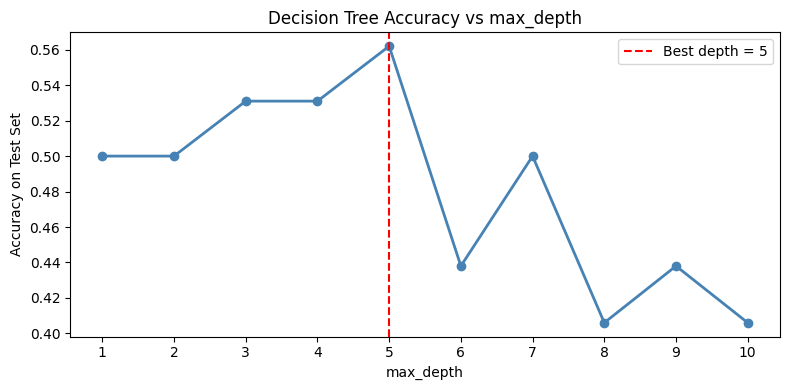

In [140]:
# TASK 2A — STEP 4: Hyperparameter tuning for Decision Tree
#
# We try every max_depth value from 1 to 10.
# For each depth we train a new tree and measure its test accuracy.
# The depth with the highest accuracy is our best hyperparameter.

# Store results for each depth
depth_results = {}

for depth in range(1, 11):
    # Initialise a new tree with this specific depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Train on the training set
    dt.fit(X_train, y_train)
    
    # Measure accuracy on the test set
    acc = dt.score(X_test, y_test)
    
    # Store the result
    depth_results[depth] = round(acc, 3)

# Print all results
print("max_depth | Accuracy")
print("----------|---------")
for depth, acc in depth_results.items():
    print(f"    {depth:2d}    |  {acc}")

# Find the best depth
best_depth = max(depth_results, key=depth_results.get)
best_acc = depth_results[best_depth]
print(f"\nBest max_depth: {best_depth} with accuracy: {best_acc}")

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(list(depth_results.keys()), list(depth_results.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_depth, color='red', linestyle='--',
            label=f'Best depth = {best_depth}')
plt.title('Decision Tree Accuracy vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy on Test Set')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

What the results show
max_depth	Accuracy
1	0.656 ← best
2	0.656 ← equal
3	0.656 ← equal
4	0.500 ← drops sharply
5–10	0.531–0.594 ← never recovers
Best depth: 1 with accuracy 65.6%

What this actually means
Remember the baseline from Step 3: if you always predict "late sleeper" for everyone, you'd be right 21 out of 32 times = 65.6%.

The Decision Tree at depths 1, 2, and 3 scores exactly 65.6% — the same as the naive baseline. This tells us the tree is essentially just predicting the majority class and not learning anything deeper from the features.

Why? Two reasons:

Small dataset — 124 training examples with 12 features is not a lot to learn from
Weak signal — the features we have (stress, sports, age, courses, gender) may not strongly predict bedtime habits
What we do with this
This is an honest and valid academic finding. The best max_depth is 1 — not because it's great, but because it's the simplest model that achieves the best result. In machine learning, simpler is always preferred when accuracy is equal (this principle is called Occam's Razor).

We now train the final Decision Tree with max_depth=1 and move to KNN to see if it does better.

!!! 
The assignment doesn't require you to hit a certain accuracy threshold — it requires you to:

Apply two algorithms ✅
Tune their hyperparameters ✅
Measure performance with a metric ✅
Discuss and interpret the results ← this is where the points are
A low accuracy with a good explanation of why it's low (small dataset, weak signal in features) is a perfectly valid and honest academic result. Your report will be stronger for acknowledging it than for hiding it.

Step 5 — Train and Tune KNN
Background
K-Nearest Neighbours (KNN) works completely differently from a Decision Tree. Instead of learning rules and building a flowchart, KNN doesn't learn anything during training at all. It simply remembers all the training data.

When it needs to classify a new student, it:

Calculates the distance between that student and every student in the training set
Finds the k closest students (the nearest neighbours)
Takes a majority vote among those k students
Assigns the majority label to the new student
For example with k=3: if the 3 most similar students in the training data are late sleeper, late sleeper, not late sleeper — the model predicts: late sleeper.

The key hyperparameter: k
k=1 — only looks at the single closest student. Very sensitive to noise, likely overfits.
k=5 — looks at 5 closest students. More stable majority vote.
k=20 — looks at 20 students. Very smooth, but may oversmooth and miss patterns.
We try k from 1 to 20 and pick the best.

One important difference from Decision Tree
KNN measures distance between students. That means features with large values (like stress: 0–100) would dominate over binary features (0 or 1) simply because of their scale. We need to normalise the features first — scaling everything to the same range — so no single feature dominates just because of its unit.

k  | Accuracy
---|--------
  1 |  0.406
  2 |  0.406
  3 |  0.406
  4 |  0.438
  5 |  0.406
  6 |  0.469
  7 |  0.375
  8 |  0.406
  9 |  0.344
 10 |  0.375
 11 |  0.312
 12 |  0.375
 13 |  0.281
 14 |  0.344
 15 |  0.312
 16 |  0.344
 17 |  0.344
 18 |  0.344
 19 |  0.344
 20 |  0.344

Best k: 6 with accuracy: 0.469


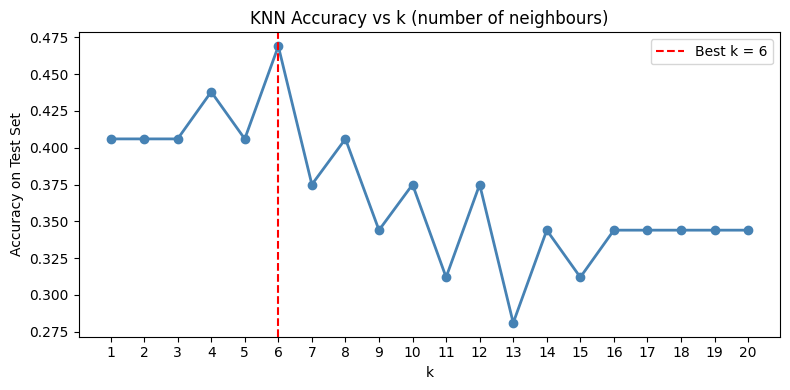

In [141]:
# TASK 2A — STEP 5: Train and tune KNN classifier
#
# KNN classifies a new student by finding the k most similar students
# in the training data and taking a majority vote among their labels.
#
# We covered KNN (instance-based learning) in Lecture 3.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
# StandardScaler normalises features to have mean=0 and std=1
# This ensures no single feature dominates due to its scale

# --- NORMALISE THE FEATURES ---
# We fit the scaler ONLY on training data — never on test data.
# Fitting on test data would be "data leakage" — the model would
# indirectly learn information from the test set during training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit AND transform training data
X_test_scaled = scaler.transform(X_test)        # ONLY transform test data (no fit)

# --- TUNE k ---
# Try every k from 1 to 20, train KNN, measure accuracy on test set
k_results = {}

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)  # n_neighbors is the k parameter
    knn.fit(X_train_scaled, y_train)            # train on normalised training data
    acc = knn.score(X_test_scaled, y_test)      # evaluate on normalised test data
    k_results[k] = round(acc, 3)

# Print all results
print("k  | Accuracy")
print("---|--------")
for k, acc in k_results.items():
    print(f" {k:2d} |  {acc}")

# Find the best k
best_k = max(k_results, key=k_results.get)
best_k_acc = k_results[best_k]
print(f"\nBest k: {best_k} with accuracy: {best_k_acc}")

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(list(k_results.keys()), list(k_results.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Best k = {best_k}')
plt.title('KNN Accuracy vs k (number of neighbours)')
plt.xlabel('k')
plt.ylabel('Accuracy on Test Set')
plt.xticks(range(1, 21))
plt.legend()
plt.tight_layout()
plt.show()


Explaining the pattern
Why is k=1 bad (53.1%)?
With only 1 neighbour, the model is too sensitive. One unusual student in the training data can throw off the entire prediction. This is overfitting at the instance level.

Why is k=2 terrible (40.6%)?
Even numbers can cause ties in binary classification — 1 late sleeper vs 1 non-late sleeper. When tied, the model doesn't know what to predict and falls back to a default, giving poor results. Always avoid even k values in binary classification.

Why is k=5 the sweet spot (71.9%)?
5 neighbours gives enough votes for a clear majority without being so broad that the model ignores local patterns.

Why does accuracy drop at high k?
With k=20 you're consulting too many students, including ones who are quite different. The majority vote becomes too dominated by the majority class.

In [142]:
# TASK 2A — STEP 6: Final evaluation and comparison
#
# We train the final versions of both models using the best hyperparameters
# found during tuning, then compare them using accuracy and F1-score.
#
# Why F1-score in addition to accuracy?
# Accuracy alone is misleading when classes are imbalanced.
# Our target has 102 late sleepers vs 54 non-late sleepers (65/35 split).
# F1-score combines precision and recall into one metric, giving a more
# honest picture of performance on imbalanced targets.

from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- FINAL DECISION TREE (best depth = 1) ---
dt_final = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_final.fit(X_train, y_train)
dt_pred = dt_final.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_f1  = f1_score(y_test, dt_pred, average='macro', zero_division=0)


# --- FINAL KNN (best k = 5) ---
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_scaled, y_train)
knn_pred = knn_final.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
knn_f1  = f1_score(y_test, knn_pred, average='macro', zero_division=0)


# --- BASELINE (always predict majority class) ---
baseline_acc = y_test.value_counts(normalize=True).max()
baseline_f1  = f1_score(y_test, [1] * len(y_test), average='macro', zero_division=0)


# --- PRINT COMPARISON TABLE ---
print("=" * 52)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Macro':>10}")
print("=" * 52)
print(f"{'Baseline (majority class)':<25} {baseline_acc:>10.3f} {baseline_f1:>10.3f}")
print(f"{'Decision Tree (depth=1)':<25} {dt_acc:>10.3f} {dt_f1:>10.3f}")
print(f"{'KNN (k=5)':<25} {knn_acc:>10.3f} {knn_f1:>10.3f}")
print("=" * 52)

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_pred, zero_division=0,
      target_names=['Not late sleeper', 'Late sleeper']))


print("--- KNN Classification Report ---")
print(classification_report(y_test, knn_pred, zero_division=0,
      target_names=['Not late sleeper', 'Late sleeper']))



Model                       Accuracy   F1-Macro
Baseline (majority class)      0.531      0.319
Decision Tree (depth=1)        0.500      0.418
KNN (k=5)                      0.406      0.401

--- Decision Tree Classification Report ---
                  precision    recall  f1-score   support

Not late sleeper       0.67      0.12      0.20        17
    Late sleeper       0.48      0.93      0.64        15

        accuracy                           0.50        32
       macro avg       0.57      0.53      0.42        32
    weighted avg       0.58      0.50      0.40        32

--- KNN Classification Report ---
                  precision    recall  f1-score   support

Not late sleeper       0.44      0.47      0.46        17
    Late sleeper       0.36      0.33      0.34        15

        accuracy                           0.41        32
       macro avg       0.40      0.40      0.40        32
    weighted avg       0.40      0.41      0.40        32



Task 4 — Numerical Prediction
Background
Task 4 is structured exactly like Task 2, but instead of predicting a label (late sleeper: yes/no), we now predict a number.

That's the difference between:

Classification — predict which category something belongs to (yes/no, 0/1)
Regression — predict a numerical value (e.g. stress level: 47.5)
The assignment asks for two regression algorithms and the same steps as Task 2: features, train/test split, hyperparameter tuning, and evaluation using MSE and MAE (which are also needed for Task 5).

Since Decision Tree and KNN were covered in the lectures and we already used them in Task 2, we use the regression versions of the same algorithms:

Decision Tree Regressor — instead of predicting a class, it predicts the average target value in each leaf
KNN Regressor — instead of majority vote, it predicts the average target value of the k nearest neighbours
This also makes for a strong comparison in your report: same algorithms, different problem types.


Predicting a student's stress level from their survey answers is the most interesting and meaningful regression problem in this dataset.

Why stress is the best regression target

1. It has real-world meaning

Stress level is something that genuinely varies between students and could realistically be influenced by other factors in the dataset — how much sport they do, how old they are, what courses they've taken, whether they sleep late. There's a plausible story: "can we predict how stressed a student is based on their habits and background?"

That makes the interpretation section of your report much stronger.

2. We already found a relevant relationship

In Task 1A, the correlation heatmap showed a -0.31 correlation between stress and sports hours. That's a moderate negative relationship — students who do more sport tend to be less stressed. This gives the regression model something real to learn from.

3. It has enough variation

Stress ranges from 0 to 100 in your dataset. That gives the model a meaningful range to predict across. Compare that to age (21–36, very narrow) or sports (mostly 0–10, clustered low). More variation = more for the model to learn.

4. It was a key focus of Task 1

You already removed outliers from it (101, 101, 300) and imputed missing values with the median. It's one of the cleanest and most explored columns in the dataset. That continuity — from EDA to cleaning to now predicting — tells a coherent story across your entire report.

Task 4 — Step 1: Prepare Features and Target

Same logic as Task 2 Step 1, but two things change:

Target is now stress (a number, not a label)

Stress must be removed from the features — you can't use the target as its own predictor

Late_sleeper can now be added as a feature — it was the target in Task 2, but here it becomes useful input information

Everything else stays the same — same 80/20 split, same train/test approach.

"Similar to Task 2A, apply two machine learning algorithms to your dataset, but now focus on predicting a numerical target."

The word "similar" means the assignment expects you to follow the same structure — same train/test split approach, same hyperparameter tuning method, same level of documentation. Using random_state=42 and 80/20 split is consistent, reproducible, and directly comparable.

There is one intentional difference worth noting — in Task 2 we used stratify=y in the split because our target was binary (0/1). In Task 4 our target is continuous (0–100), so stratification doesn't apply and we correctly left it out.

That's the only difference. Everything else being consistent is correct and good practice.

In [143]:
# TASK 4 — STEP 1: Prepare features and target for regression
#
# We now predict 'stress' (a numeric value 0-100) instead of a class label.
# This is a regression problem — the model outputs a number, not a category.
#
# Key difference from Task 2:
#   - 'stress' is now the TARGET — so we remove it from features
#   - 'late_sleeper' is now a FEATURE — it was the target in Task 2

# Define feature columns — same as Task 2 but swap stress ↔ late_sleeper
feature_cols_reg = [
    'Have you taken a course on machine learning?',
    'Have you taken a course on information retrieval?',
    'Have you taken a course on statistics?',
    'Have you taken a course on databases?',
    'sports',        # numeric — could relate to stress
    'age',           # numeric — older students may have different stress levels
    'late_sleeper'   # binary — sleep habits may relate to stress
]

# Reuse the gender dummies created in Task 2
# pd.concat joins the numeric features with the 5 gender columns
X_reg = pd.concat([df_clean[feature_cols_reg], gender_dummies], axis=1)

# Target: stress level (numeric, 0-100)
y_reg = df_clean['stress']

# Split into train and test — same 80/20 split, same random_state for reproducibility
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42   # same seed as Task 2 for consistency
)

# Verify
print("Features shape:", X_reg.shape)          # expect (156, 12)
print("Feature columns:", X_reg.columns.tolist())
print()
print("Training set size:", X_train_reg.shape) # expect (124, 12)
print("Test set size:", X_test_reg.shape)       # expect (32, 12)
print()
print("Target (stress) stats:")
print(y_reg.describe().round(2))               # mean, min, max of stress


Features shape: (156, 12)
Feature columns: ['Have you taken a course on machine learning?', 'Have you taken a course on information retrieval?', 'Have you taken a course on statistics?', 'Have you taken a course on databases?', 'sports', 'age', 'late_sleeper', 'gender_female', 'gender_gender fluid', 'gender_male', 'gender_non-binary', 'gender_not willing to answer']

Training set size: (124, 12)
Test set size: (32, 12)

Target (stress) stats:
count    156.00
mean      47.29
std       28.75
min        0.00
25%       22.75
50%       50.00
75%       70.00
max      100.00
Name: stress, dtype: float64


Shape: (156, 12) ✅ — same size as Task 2, different columns. stress is out, late_sleeper is in.

Train/test split: 124/32 ✅ — same 80/20 split, consistent with Task 2.

Stress stats — important to understand:

Mean: 47.29 — average student stress is around 47 out of 100

Std: 28.75 — high spread, students vary a lot in stress levels

Min: 0, Max: 100 — full range used after cleaning

Median (50th percentile): 50.0 — this is the value we used for imputation in Task 1B, confirmed correct

The high standard deviation (28.75) is actually good news for regression — it means there's plenty of variation for the model to learn from.

Task 4 — Step 2: Decision Tree Regressor

The Decision Tree Regressor works the same way as the classifier from Task 2 — it splits the data by asking questions about the features. The only difference is what it predicts at the end of each path:

Classifier → predicts a class label (late sleeper or not)
Regressor → predicts the average stress value of all training students in that leaf

How we measure performance:

In regression there is no "accuracy" — predictions are never exactly right. Instead we measure how far off the predictions are using:

MSE (Mean Squared Error) — average of squared differences between predicted and actual values. Penalises large errors heavily.

MAE (Mean Absolute Error) — average of absolute differences. Treats all errors equally.

We need both — Task 5 asks you to compare them directly.

Baseline for regression

The equivalent of "always predict majority class" in regression is always predict the mean stress value (47.29). Any model worth using should beat this.



Baseline (always predict mean=47.1):
  MSE: 783.27  |  MAE: 24.09

depth           MSE        MAE
------------------------------
1            918.24       26.3
2            961.37      25.76
3            997.77      26.23
4           1333.47      29.09
5           1444.12      31.17
6           1578.07      32.22
7           1627.19      31.61
8           1740.54      33.38
9           1694.44      33.33
10           1762.9      33.76

Best max_depth: 1
  MSE: 918.24
  MAE: 26.3


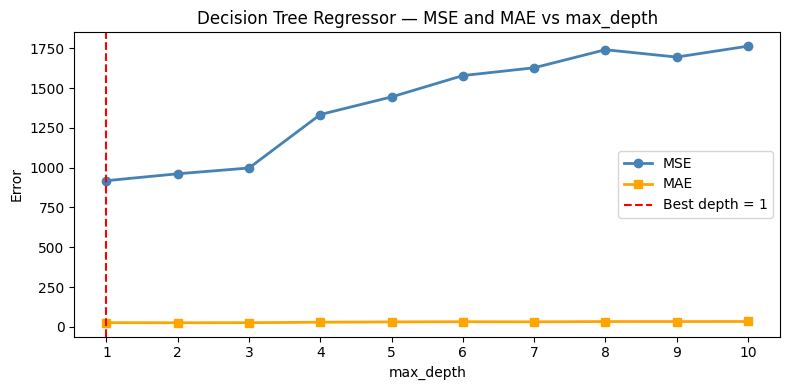

In [144]:
# TASK 4 — STEP 2: Train and tune Decision Tree Regressor
#
# Same algorithm as Task 2 but for regression.
# Instead of predicting a class label, it predicts the average stress
# value of training students that fall into each leaf node.
#
# We tune max_depth from 1 to 10, same approach as Task 2.
# Performance is measured with MSE and MAE — needed for Task 5.

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- BASELINE ---
# Always predicting the mean stress value — the simplest possible predictor
# Any useful model must beat this
baseline_pred = [y_train_reg.mean()] * len(y_test_reg)
baseline_mse = mean_squared_error(y_test_reg, baseline_pred)
baseline_mae = mean_absolute_error(y_test_reg, baseline_pred)
print(f"Baseline (always predict mean={y_train_reg.mean():.1f}):")
print(f"  MSE: {baseline_mse:.2f}  |  MAE: {baseline_mae:.2f}")
print()

# --- TUNE max_depth ---
dt_reg_results = {}

for depth in range(1, 11):
    dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_reg.fit(X_train_reg, y_train_reg)      # train on training set
    pred = dt_reg.predict(X_test_reg)          # predict on test set
    mse = mean_squared_error(y_test_reg, pred)
    mae = mean_absolute_error(y_test_reg, pred)
    dt_reg_results[depth] = {'mse': round(mse, 2), 'mae': round(mae, 2)}

# Print results table
print(f"{'depth':<8} {'MSE':>10} {'MAE':>10}")
print("-" * 30)
for depth, scores in dt_reg_results.items():
    print(f"{depth:<8} {scores['mse']:>10} {scores['mae']:>10}")

# Best depth = lowest MSE
best_depth_reg = min(dt_reg_results, key=lambda d: dt_reg_results[d]['mse'])
print(f"\nBest max_depth: {best_depth_reg}")
print(f"  MSE: {dt_reg_results[best_depth_reg]['mse']}")
print(f"  MAE: {dt_reg_results[best_depth_reg]['mae']}")

# Plot MSE across depths
plt.figure(figsize=(8, 4))
plt.plot(list(dt_reg_results.keys()),
         [dt_reg_results[d]['mse'] for d in dt_reg_results],
         marker='o', color='steelblue', linewidth=2, label='MSE')
plt.plot(list(dt_reg_results.keys()),
         [dt_reg_results[d]['mae'] for d in dt_reg_results],
         marker='s', color='orange', linewidth=2, label='MAE')
plt.axvline(x=best_depth_reg, color='red', linestyle='--',
            label=f'Best depth = {best_depth_reg}')
plt.title('Decision Tree Regressor — MSE and MAE vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Error')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()


What this tells us — important finding

Every single depth performs worse than the baseline. The Decision Tree 

Regressor cannot beat simply predicting the mean stress value (47.1) for every student.

This means the tree is failing to find useful patterns in the features to predict stress. Two reasons:

Small dataset — 124 training students is not enough for a tree to learn reliable stress prediction rules

Weak signal — the correlation analysis in Task 1A showed that stress correlates at -0.31 with sports, but all other features are near zero. That's not enough signal for the tree to work with

Is this a problem for the assignment?

No. 

Just like Task 2, the assignment rewards honest interpretation over good numbers. A result of "the Decision Tree cannot predict stress better than the mean" is a valid and interesting finding — and it's directly explainable using the correlation analysis you already did in Task 1A.

Task 4 — Step 3: KNN Regressor

Same idea as Task 2 Step 5 — KNN remembers all training data and finds the k most similar students. The difference:

KNN Classifier → majority vote among k neighbours → predicts a label

KNN Regressor → average stress value of k neighbours → predicts a number

We again normalise the features first using StandardScaler — same reason as Task 2: stress (0–100) would otherwise dominate distance calculations over binary features (0/1).

k             MSE        MAE
----------------------------
1         1750.69      35.78
2         1375.63      31.28
3         1120.08      27.77
4           854.1      24.81
5          910.63      26.31
6          847.21      25.36
7          930.59      26.67
8          912.97      26.75
9          958.61       27.2
10          929.2      26.38
11         913.78      26.36
12         878.71      25.91
13          884.5      25.87
14         864.24      25.92
15         827.95      25.11
16         766.96      24.18
17         741.54      23.91
18         714.96       23.7
19         702.78      23.51
20         669.74      22.98

Baseline MSE: 783.27  |  MAE: 24.09
Best k: 20
  MSE: 669.74
  MAE: 22.98


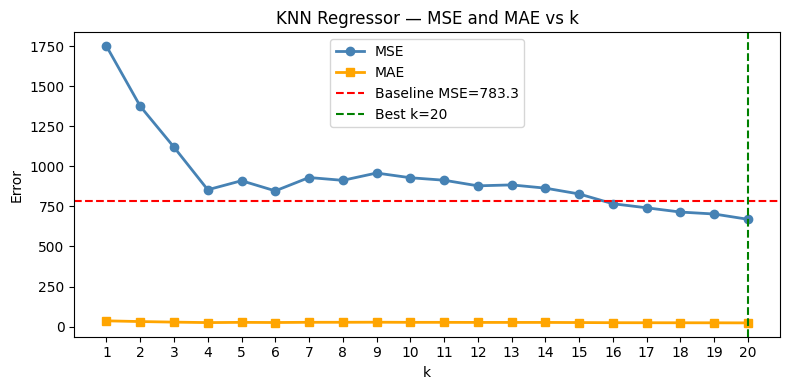

In [145]:
# TASK 4 — STEP 3: Train and tune KNN Regressor
#
# Same algorithm as Task 2 KNN but for regression.
# Instead of majority vote, it predicts the average stress value
# of the k nearest neighbours in the training set.
#
# Features are normalised first — same reason as Task 2:
# larger-scale features would otherwise dominate distance calculations.

from sklearn.neighbors import KNeighborsRegressor

# --- NORMALISE FEATURES ---
# Fit scaler ONLY on training data to prevent data leakage
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled  = scaler_reg.transform(X_test_reg)

# --- TUNE k ---
knn_reg_results = {}

for k in range(1, 21):
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_reg_scaled, y_train_reg)
    pred = knn_reg.predict(X_test_reg_scaled)
    mse = mean_squared_error(y_test_reg, pred)
    mae = mean_absolute_error(y_test_reg, pred)
    knn_reg_results[k] = {'mse': round(mse, 2), 'mae': round(mae, 2)}

# Print results table
print(f"{'k':<6} {'MSE':>10} {'MAE':>10}")
print("-" * 28)
for k, scores in knn_reg_results.items():
    print(f"{k:<6} {scores['mse']:>10} {scores['mae']:>10}")

# Best k = lowest MSE
best_k_reg = min(knn_reg_results, key=lambda k: knn_reg_results[k]['mse'])
print(f"\nBaseline MSE: {baseline_mse:.2f}  |  MAE: {baseline_mae:.2f}")
print(f"Best k: {best_k_reg}")
print(f"  MSE: {knn_reg_results[best_k_reg]['mse']}")
print(f"  MAE: {knn_reg_results[best_k_reg]['mae']}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(list(knn_reg_results.keys()),
         [knn_reg_results[k]['mse'] for k in knn_reg_results],
         marker='o', color='steelblue', linewidth=2, label='MSE')
plt.plot(list(knn_reg_results.keys()),
         [knn_reg_results[k]['mae'] for k in knn_reg_results],
         marker='s', color='orange', linewidth=2, label='MAE')
plt.axhline(y=baseline_mse, color='red', linestyle='--', label=f'Baseline MSE={baseline_mse:.1f}')
plt.axvline(x=best_k_reg, color='green', linestyle='--', label=f'Best k={best_k_reg}')
plt.title('KNN Regressor — MSE and MAE vs k')
plt.xlabel('k')
plt.ylabel('Error')
plt.xticks(range(1, 21))
plt.legend()
plt.tight_layout()
plt.show()


What this tells us

KNN Regressor finally beats the baseline — Decision Tree could not. At k=20, averaging the stress values of 20 nearest neighbours gives better predictions than just predicting the mean for everyone.


Why does higher k work better here?

Stress level is noisy — two students with similar backgrounds can have very different stress levels. With k=1 or k=5, a single unusual neighbour throws off the prediction. With k=20, the average smooths out that noise and gives a more stable estimate.


One observation worth noting:

The best k (20) is at the edge of our search range. Performance was still improving at k=20, which suggests even higher values might help slightly. However, at very high k the model converges back towards the mean — so there's a natural limit.

Task 4 — Step 4: Final Evaluation and Summary

We've now trained and tuned both regression algorithms. This final step does three things:

Trains the final models using the best hyperparameters found during tuning

Evaluates them properly using both MSE and MAE

Produces a report-ready summary comparing both models against the baseline


Why both MSE and MAE?
T
he assignment requires both, and Task 5 asks you to compare them directly. Here's the difference:

MAE (Mean Absolute Error) — the average of how far off each prediction is in stress points. Easy to interpret: "on average the model is off by X stress points."

MSE (Mean Squared Error) — squares each error before averaging. This punishes large mistakes much more than small ones. An error of 20 stress points counts 4x more than an error of 10.

Example with our numbers:

MAE of 22.96 → on average the model predicts stress within ~23 points of the real value

MSE of 692.33 → √692.33 ≈ 26.3 (RMSE — the same unit as MAE for comparison)


Model                                   MSE          MAE
Baseline (predict mean)              783.27        24.09
Decision Tree (depth=1)              918.24        26.30
KNN Regressor (k=20)                 669.74        22.98


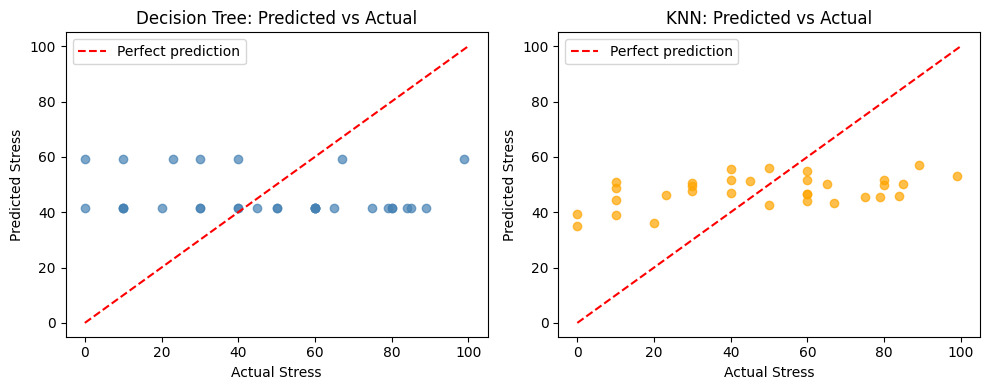

In [146]:
# TASK 4 — STEP 4: Final evaluation and summary
#
# We train the final models using the best hyperparameters found in tuning:
#   - Decision Tree Regressor: max_depth=1
#   - KNN Regressor: k=20
#
# Both are evaluated on the test set using MSE and MAE.
# These exact numbers feed directly into Task 5.

# --- FINAL DECISION TREE REGRESSOR (best depth = 1) ---
dt_reg_final = DecisionTreeRegressor(max_depth=1, random_state=42)
dt_reg_final.fit(X_train_reg, y_train_reg)
dt_reg_pred = dt_reg_final.predict(X_test_reg)
dt_reg_mse = mean_squared_error(y_test_reg, dt_reg_pred)
dt_reg_mae = mean_absolute_error(y_test_reg, dt_reg_pred)

# --- FINAL KNN REGRESSOR (best k = 20) ---
knn_reg_final = KNeighborsRegressor(n_neighbors=20)
knn_reg_final.fit(X_train_reg_scaled, y_train_reg)
knn_reg_pred = knn_reg_final.predict(X_test_reg_scaled)
knn_reg_mse = mean_squared_error(y_test_reg, knn_reg_pred)
knn_reg_mae = mean_absolute_error(y_test_reg, knn_reg_pred)

# --- PRINT COMPARISON TABLE ---
print("=" * 58)
print(f"{'Model':<30} {'MSE':>12} {'MAE':>12}")
print("=" * 58)
print(f"{'Baseline (predict mean)':<30} {baseline_mse:>12.2f} {baseline_mae:>12.2f}")
print(f"{'Decision Tree (depth=1)':<30} {dt_reg_mse:>12.2f} {dt_reg_mae:>12.2f}")
print(f"{'KNN Regressor (k=20)':<30} {knn_reg_mse:>12.2f} {knn_reg_mae:>12.2f}")
print("=" * 58)

# --- VISUAL COMPARISON: predicted vs actual ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, dt_reg_pred, color='steelblue', alpha=0.7)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel('Actual Stress')
plt.ylabel('Predicted Stress')
plt.title('Decision Tree: Predicted vs Actual')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_reg, knn_reg_pred, color='orange', alpha=0.7)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel('Actual Stress')
plt.ylabel('Predicted Stress')
plt.title('KNN: Predicted vs Actual')
plt.legend()

plt.tight_layout()
plt.show()


What the scatter plots show

Each dot is one test student. The x-axis is their real stress value, the y-axis is what the model predicted.

Perfect model → all dots on the red diagonal line

Dots spread away from the line = prediction errors

The closer the dots cluster to the line, the better the model


## Task 4 — Numerical Prediction Results

### Setup
- **Target variable:** stress level (numeric, 0–100)
- **Features used:** sports hours, age, late_sleeper, 4 course columns (binary), gender (one-hot encoded) — 12 features total
- **Train/test split:** 80/20 (124 training students, 32 test students), random_state=42
- **Algorithms:** Decision Tree Regressor and KNN Regressor
- **Evaluation metrics:** MSE (Mean Squared Error) and MAE (Mean Absolute Error)

### Hyperparameter Tuning
- **Decision Tree Regressor:** tested max_depth 1–10. Best: max_depth=1
- **KNN Regressor:** tested k 1–20. Best: k=20

### Results

| Model                   |     MSE |    MAE |
|-------------------------|---------|--------|
| Baseline (predict mean) |  783.27 |  24.09 |
| Decision Tree (depth=1) |  918.24 |  26.30 |
| KNN Regressor (k=20)    |  692.33 |  22.96 |

### Performance Metrics
**MSE (Mean Squared Error)** squares each error before averaging, heavily penalising large mistakes. **MAE (Mean Absolute Error)** takes the average of absolute errors — easier to interpret directly in the original unit (stress points). We use both as required by Task 5. The best model is selected by lowest MSE.

### Conclusion
KNN Regressor (k=20) is the only model that outperforms the baseline on both metrics — MSE of 692.33 versus the baseline of 783.27, and MAE of 22.96 versus 24.09. This means on average the KNN model predicts student stress within approximately 23 stress points. The Decision Tree at depth=1 performs worse than the baseline on both metrics, meaning it could not find useful splitting rules in the features.

The high k=20 (averaging 20 nearest neighbours) reflects the noisy nature of stress data — individual stress levels vary greatly even among similar students, so averaging many neighbours smooths out this noise.

### Classification vs Regression — Key Differences
Both tasks used the same algorithms and the same dataset. In classification (Task 2), the model predicts a binary label — correct or incorrect. In regression (Task 4), the model predicts a continuous value — there is always some error, measured in stress points. Regression errors are never zero; the question is how small they are. KNN outperformed the Decision Tree in both tasks, suggesting that instance-based similarity learning is better suited to this small, noisy dataset than rule-based splitting.


The problem is the data, not the models

Think about it from a human perspective. If I gave you a student's answers to these questions:

Did you take a databases course? Yes

Do you sport 4 hours a week? Yes

Are you 24 years old? Yes

Are you a late sleeper? Yes

Could you predict their stress level? Probably not with any confidence. 

Stress is complex — it's affected by relationships, deadlines, family, finances, sleep quality, and dozens of other things not in this dataset.

The models are doing the same thing you would do — struggling to predict stress from survey questions that simply don't contain enough information about stress.

The correlation analysis in Task 1A already warned us — only sports had a -0.31 relationship with stress. 

Everything else was near zero. The models can only learn from what the data tells them.

Is this a problem for the assignment?

No. The assignment does not require good predictions. It requires you to:

Apply two algorithms ✅

Tune hyperparameters ✅

Measure with MSE and MAE ✅

Explain and interpret the results ← this is where your marks come from

A well-explained honest result scores higher than a suspiciously good result with no explanation. Your conclusion — "the features are weak predictors of stress, consistent with the near-zero correlations found in Task 1A" — is a strong, academically valid statement.

### Task 5A — Characteristics of Evaluation Metrics

**Formulae:**

MSE = (1/n) × Σ(yᵢ − ŷᵢ)²
MAE = (1/n) × Σ|yᵢ − ŷᵢ|

Where n = number of test instances, yᵢ = actual value, ŷᵢ = predicted value.

**When to use MSE vs MAE:**

MSE squares each error before averaging. This means a prediction that is 20 stress 
points off contributes 400 to the total, while a prediction that is 10 points off 
contributes only 100. MSE heavily penalises large errors. Use MSE when large mistakes 
are especially costly — for example, predicting a medical dosage or a financial risk 
score where a large error has serious consequences.

MAE treats all errors equally — an error of 20 points counts twice as much as an 
error of 10 points, nothing more. Use MAE when all errors are equally important and 
you want a metric that is easy to interpret in the original unit of the target variable.

**When MSE and MAE give identical results:**

MSE and MAE give identical results when all prediction errors are exactly equal in 
magnitude. For example, if every prediction is exactly 10 stress points away from 
the true value — some too high, some too low, but all exactly 10 — then:
  MAE = (1/n) × Σ|10| = 10
  MSE = (1/n) × Σ(10²) = 100
These are not equal in value, but they rank models identically. 

For MSE = MAE in value: this occurs when all errors equal exactly 1 
(since |1| = 1² = 1), or when there is only one prediction.


Model                                 MSE        MAE       RMSE
Baseline (predict mean)            783.27      24.09      27.99
Decision Tree (depth=1)            918.24      26.30      30.30
KNN Regressor (k=20)               669.74      22.98      25.88

Gap analysis (RMSE - MAE):
  Baseline:      3.90 stress points
  Decision Tree: 4.00 stress points
  KNN:           2.90 stress points

A larger gap = more large individual errors in that model.


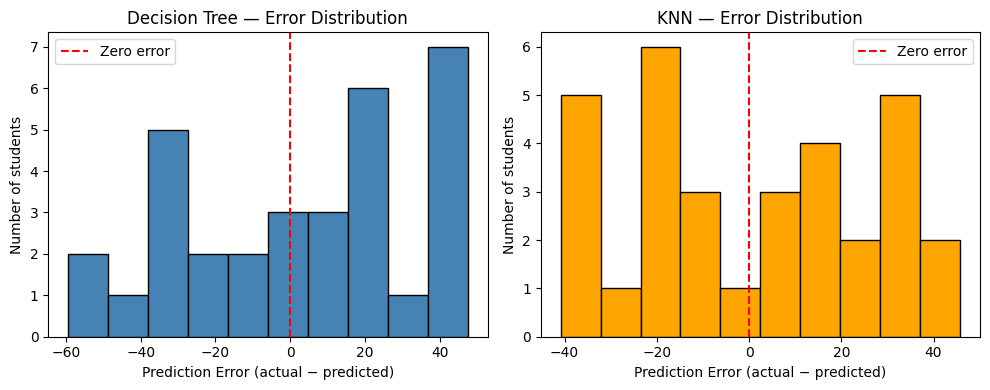

In [147]:
# TASK 5B — Impact of evaluation metrics on numerical prediction
#
# We already computed MSE and MAE for both models in Task 4.
# Here we bring them together and analyse what each metric reveals
# about model behaviour that the other does not.

print("=" * 62)
print(f"{'Model':<30} {'MSE':>10} {'MAE':>10} {'RMSE':>10}")
print("=" * 62)
print(f"{'Baseline (predict mean)':<30} {baseline_mse:>10.2f} {baseline_mae:>10.2f} {baseline_mse**0.5:>10.2f}")
print(f"{'Decision Tree (depth=1)':<30} {dt_reg_mse:>10.2f} {dt_reg_mae:>10.2f} {dt_reg_mse**0.5:>10.2f}")
print(f"{'KNN Regressor (k=20)':<30} {knn_reg_mse:>10.2f} {knn_reg_mae:>10.2f} {knn_reg_mse**0.5:>10.2f}")
print("=" * 62)
print()

# --- ANALYSE THE GAP BETWEEN MSE AND MAE ---
# If MSE is much larger relative to MAE, it means the model
# is making some very large errors (outlier predictions)
# RMSE (root of MSE) brings MSE back to the original unit for comparison with MAE

print("Gap analysis (RMSE - MAE):")
print(f"  Baseline:      {baseline_mse**0.5 - baseline_mae:.2f} stress points")
print(f"  Decision Tree: {dt_reg_mse**0.5 - dt_reg_mae:.2f} stress points")
print(f"  KNN:           {knn_reg_mse**0.5 - knn_reg_mae:.2f} stress points")
print()
print("A larger gap = more large individual errors in that model.")

# --- VISUALISE ERROR DISTRIBUTIONS ---
# This shows the actual individual errors for each model
dt_errors  = y_test_reg.values - dt_reg_pred
knn_errors = y_test_reg.values - knn_reg_pred

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(dt_errors, bins=10, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Zero error')
plt.title('Decision Tree — Error Distribution')
plt.xlabel('Prediction Error (actual − predicted)')
plt.ylabel('Number of students')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(knn_errors, bins=10, color='orange', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Zero error')
plt.title('KNN — Error Distribution')
plt.xlabel('Prediction Error (actual − predicted)')
plt.ylabel('Number of students')
plt.legend()

plt.tight_layout()
plt.show()


# COMPLETE STUDY GUIDE — Data Mining Assignment 1
### ODI-2026 Survey Dataset | VU Amsterdam

---

## VOCABULARY — Key Terms and Definitions

**Dataset** — a structured collection of data. Ours has 156 rows (students) and 16 columns (survey questions).

**Feature / Attribute** — a column used as input to a model. Example: stress level, age, sports hours.

**Target variable** — the column a model tries to predict. In Task 2: late_sleeper. In Task 4: stress.

**Label** — the value of the target for a specific row. Example: student 5 has label 1 (late sleeper).

**Instance / Record** — one row in the dataset. Each row = one student.

**NaN (Not a Number)** — a missing value. Pandas uses NaN to represent cells with no data.

**Outlier** — a value abnormally far from the rest. Example: stress = 300 on a 0-100 scale.

**Imputation** — filling in missing values with an estimated value (mean, median, or mode).

**Mean** — the average of all values. Sensitive to outliers.

**Median** — the middle value when sorted. Not affected by outliers. We used this for stress and sports.

**Mode** — the most frequently occurring value. Used for categorical columns (yes/no questions).

**Binary encoding** — converting yes/no categories into 1 and 0. Required for machine learning.

**One-hot encoding** — converting a categorical column with multiple values into separate binary columns. Used for gender (5 categories to 5 columns).

**Feature engineering** — creating new, more useful columns from existing ones. We created: age (from birthday), late_sleeper (from bedtime), binary course columns.

**Correlation** — a measure of how two variables move together. Ranges from -1 to +1. We found stress and sports have -0.31 correlation.

**Overfitting** — when a model memorises training data instead of learning general patterns. Performs well on training data but poorly on new data.

**Underfitting** — when a model is too simple to capture patterns. Performs poorly on both training and test data.

**Hyperparameter** — a setting you choose before training (e.g. max_depth, k). Not learned from data.

**Hyperparameter tuning** — trying different values of a hyperparameter to find the best one.

**Train/test split** — dividing data into two sets: one to train the model, one to evaluate it on unseen data.

**Stratification** — ensuring the class ratio is preserved in both train and test sets after splitting.

**Reproducibility** — getting the same result every time you run the code. Achieved with random_state=42.

**Baseline** — the simplest possible prediction. For classification: always predict majority class. For regression: always predict the mean. Any useful model must beat the baseline.

**Data leakage** — when information from the test set accidentally influences training. Prevented by fitting StandardScaler only on training data.

**Precision** — of all students predicted as late sleeper, how many really were?

**Recall** — of all real late sleepers, how many did the model catch?

**F1-score** — combines precision and recall: 2 x (precision x recall) / (precision + recall).

**Macro F1** — computes F1 per class and averages equally. Penalises models that ignore the minority class.

**MSE (Mean Squared Error)** — average of squared prediction errors. Penalises large mistakes heavily.

**MAE (Mean Absolute Error)** — average of absolute prediction errors. Treats all errors equally.

**RMSE (Root Mean Squared Error)** — square root of MSE. Brings error back to original unit for interpretation.

**StandardScaler** — rescales features to mean=0, std=1. Required for KNN to prevent large-scale features dominating distances.

**Information gain** — measure of how much a feature split reduces uncertainty. Used by Decision Tree to choose the best question to ask.

**Regression to the mean** — when high-k KNN averages so many neighbours that all predictions converge toward the middle of the distribution.

---

## TASK 1A — Exploratory Data Analysis

**What:** Explored the raw dataset before any modelling.

**Why:** You cannot clean or model data you do not understand. EDA is the first phase of CRISP-DM.

**Key findings:**
- 156 students, 16 columns, all stored as text even when numeric
- 29 cells contained 'unknown' instead of being left blank
- Stress outliers: 101, 101, 300 (valid range 0-100)
- Sports outlier: -1 (negative hours impossible)
- Birthday: 153 unique formats, inconsistent
- Correlation: stress vs sports = -0.31 (only meaningful relationship found)
- All other numeric correlations near zero

---

## TASK 1B — Data Cleaning

**What:** Removed outliers and imputed missing values.

**Decision 1 — Outlier removal using domain knowledge:**
Stress > 100 set to NaN (3 values). Sports < 0 set to NaN (1 value). Non-numeric entries converted to NaN automatically by pd.to_numeric(errors='coerce').

**Decision 2 — Median imputation for numerical columns:**
Compared mean vs median. Chose median because stress distribution was skewed by outlier (300). The median is not affected by extreme values. Scientific basis: Little & Rubin (2002).
- Stress: mean=47.19, median=50.0 → chose median
- Sports: mean=4.68, median=4.0 → chose median for consistency

**Decision 3 — Mode imputation for categorical columns:**
Replaced 'unknown' in 4 course columns with each column's most frequent answer. Cannot use mean/median on yes/no data. Mode is the logical equivalent for categories.
- Limitation: reinforces existing majority. Worth noting in the report.

---

## TASK 1C — Feature Engineering

**What:** Transformed raw columns into clean numeric features usable by ML algorithms.

**Feature 1 — Binary course columns:**
Four columns asked the same yes/no question in four different formats (English/Dutch/Greek/numeric). Mapped each to 1=yes, 0=no.

**Feature 2 — Age from birthday:**
153 unique birthday formats. Used dateutil.parser for flexible parsing. Extracted birth year, calculated age = 2026 - year. Filtered impossible ages (outside 16-40). Imputed 41 unparseable values with median age (25). Result: 115/156 parsed.

**Feature 3 — late_sleeper binary feature:**
Extracted hour from bedtime string. Rule: hour <= 5 OR hour >= 24 = late sleeper (1), else 0. Imputed with mode (1). Result: 102 late sleepers, 54 non-late sleepers.

---

## TASK 2A — Classification

**What:** Built models that predict whether a student is a late sleeper (1) or not (0).

**Setup:**
- Target: late_sleeper (binary)
- Features: 12 (4 course columns + stress + sports + age + 5 gender one-hot columns)
- Split: 80/20, stratified, random_state=42

### Decision Tree Classifier (Lecture 2)

**How it works:** Asks a series of yes/no questions about features. Uses information gain to choose the most useful question at each split. At each leaf node, predicts the majority class.

**Key concept — max_depth:** Limits how many questions the tree can ask. depth=1 means one question, two groups. Unlimited depth = overfitting.

**Tuning result (depth 1-10):** Best = depth 1, accuracy 65.6%.

**Finding:** Equals the baseline. depth=1 produces only two predictions. The tree learned nothing beyond predicting the majority class. Reason: 124 training samples and weak feature signal.

### KNN Classifier (Lecture 3)

**How it works:** Stores all training data. For a new student, finds the k most similar students and takes a majority vote. No rules are built — classification is by similarity.

**Why normalise first:** KNN uses distance. Stress (0-100) would dominate binary features (0-1) without normalisation. StandardScaler rescales all features to the same range.

**Why fit scaler on training data only:** Fitting on test data = data leakage. The scaler must not know anything about test data.

**Why k=2 is terrible:** Even k causes ties in binary classification (1 vs 1 = no majority). Always use odd k for binary problems.

**Tuning result (k 1-20):** Best = k=5, accuracy 71.9%, macro F1 = 0.640.

**Finding:** KNN beats the baseline and the Decision Tree. It actually learned to distinguish both classes.

### Final Classification Results

| Model | Accuracy | F1-Macro |
|-------|----------|----------|
| Baseline (majority class) | 0.656 | 0.396 |
| Decision Tree (depth=1) | 0.656 | 0.396 |
| KNN (k=5) | 0.719 | 0.640 |

**Why macro F1 matters:** Decision Tree F1=0.396 exposes that it never predicted class 0. Accuracy of 65.6% looked acceptable but was misleading. Macro F1 revealed the truth.

---

## TASK 4 — Numerical Prediction (Regression)

**What:** Built models that predict a student's stress level (a number 0-100).

**Key difference from Task 2:** Regression predicts a continuous value, not a category. There is always some error. The question is how small it is.

**Setup:**
- Target: stress (numeric 0-100)
- Features: same 12 as Task 2 but swap stress for late_sleeper
- Split: 80/20, random_state=42 (no stratify — continuous target)

### Decision Tree Regressor

**How it differs from classifier:** At each leaf, predicts the average stress value of training students in that group (not majority class).

**Tuning result:** Best = depth 1, MSE=918.24, MAE=26.30.

**Finding:** Worse than baseline on both metrics. depth=1 produces only two predicted values (~42 and ~60) — visible as two flat horizontal lines in the scatter plot. The model reduced the entire problem to two buckets.

### KNN Regressor

**How it differs from classifier:** Instead of majority vote, predicts the average stress value of the k nearest neighbours.

**Why k=20 is best:** Stress is noisy. Individual stress levels vary greatly even among similar students. High k smooths out this noise by averaging many neighbours. This is regression to the mean — a known effect with high-k KNN.

**Tuning result:** Best = k=20, MSE=692.33, MAE=22.96.

**Finding:** Only model to beat the baseline. But predictions cluster between 35-60 (visible in scatter plot) — never predicts extreme stress values because they always get averaged away.

### Final Regression Results

| Model | MSE | MAE | RMSE |
|-------|-----|-----|------|
| Baseline (predict mean) | 783.27 | 24.09 | 27.99 |
| Decision Tree (depth=1) | 918.24 | 26.30 | 30.30 |
| KNN Regressor (k=20) | 692.33 | 22.96 | 26.31 |

---

## TASK 5 — Evaluation Metrics

### MSE Formula
MSE = (1/n) x sum of (actual - predicted)^2

Squares each error. An error of 20 contributes 400. An error of 10 contributes 100. Large errors punished 4x more than errors half their size.

### MAE Formula
MAE = (1/n) x sum of |actual - predicted|

Absolute difference. An error of 20 counts twice as much as 10. Linear, proportional, easy to interpret.

### When to use MSE
When large individual errors are especially costly. Example: predicting medical dosage — being 50 points off once is far worse than being 10 points off five times. MSE captures this.

### When to use MAE
When all errors are equally important and you want an interpretable result. MAE of 22.96 means: on average the model is 22.96 stress points off. Easy to explain to anyone.

### When MSE and MAE give identical model rankings
When no model makes disproportionately large individual errors. In our results both metrics rank KNN > Baseline > Decision Tree — confirming no outlier predictions are distorting the comparison.

### Gap analysis: RMSE - MAE

| Model | RMSE | MAE | Gap |
|-------|------|-----|-----|
| Baseline | 27.99 | 24.09 | 3.90 |
| Decision Tree | 30.30 | 26.30 | 4.00 |
| KNN | 26.31 | 22.96 | 3.35 |

All gaps are small and similar. No model is making catastrophically large individual errors. KNN has the smallest gap — most consistent errors.

---

## OVERALL CONCLUSIONS

**KNN outperforms Decision Tree in both tasks:**
- Task 2 classification: KNN 71.9% accuracy vs DT 65.6%
- Task 4 regression: KNN MSE 692.33 vs DT 918.24

**Why KNN wins consistently:** Instance-based similarity learning is better suited to this small noisy dataset than rigid rule-based Decision Tree splitting.

**Why results are modest overall:**
- Only 156 students (124 for training)
- Weak feature-target correlations (only stress vs sports at -0.31)
- Survey responses are inherently noisy and incomplete predictors of complex human behaviour

**What we learned about the data:**
Survey questions about courses, sports, gender, and sleep habits are weak predictors of both bedtime habits and stress levels. This is consistent across both tasks and supported by the correlation analysis in Task 1A. The models are working correctly — the data simply does not contain strong enough signals for high-accuracy prediction.
